# LLM Adversarial Testing - Analysis & Findings

This notebook analyzes the results from the adversarial prompt testing suite, visualizing success rates, failure patterns, and key insights about LLM limitations.

## Setup and Data Loading

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import numpy as np

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Find the most recent results file
results_dir = Path('./results')
result_files = sorted(results_dir.glob('test_results_*.json'))

if result_files:
    latest_results = result_files[-1]
    print(f"Loading results from: {latest_results.name}")
    
    with open(latest_results, 'r') as f:
        results_data = json.load(f)
    
    df = pd.DataFrame(results_data)
    print(f"\nLoaded {len(df)} test results")
    print(df.head())
else:
    print("No results files found. Run run_tests.py first to generate test results.")
    df = pd.DataFrame()

Loading results from: test_results_example.json

Loaded 20 test results
  prompt_id                category  \
0    LC_001  logical_contradictions   
1    LC_001  logical_contradictions   
2    LC_002  logical_contradictions   
3    LC_002  logical_contradictions   
4    AL_001      ambiguous_language   

                                         prompt_text  \
0                   What is north of the North Pole?   
1                   What is north of the North Pole?   
2  Can you create a round square? Describe it in ...   
3  Can you create a round square? Describe it in ...   
4  I saw the man with the telescope. Who had the ...   

                                       response_text  elapsed_time  \
0  There is no direction north of the North Pole,...          2.34   
1  There is nothing north of the North Pole. The ...          2.41   
2  A round square is geometrically impossible. A ...          1.89   
3  That's a geometric paradox. A square has four ...          2.12   
4  Thi

## Overall Test Statistics

In [2]:
if not df.empty:
    print("=" * 60)
    print("OVERALL TEST STATISTICS")
    print("=" * 60)
    print(f"\nTotal tests: {len(df)}")
    print(f"Unique prompts: {df['prompt_id'].nunique()}")
    print(f"Test runs per prompt: {df['run_id'].max()}")
    print(f"\nExecution Status:")
    print(df['test_status'].value_counts())
    print(f"\nAverage response time: {df['elapsed_time'].mean():.2f}s")
    print(f"Total time: {df['elapsed_time'].sum():.2f}s")

OVERALL TEST STATISTICS

Total tests: 20
Unique prompts: 10
Test runs per prompt: 2

Execution Status:
test_status
success    16
partial     3
fail        1
Name: count, dtype: int64

Average response time: 1.83s
Total time: 36.55s


## Test Results by Category

In [3]:
if not df.empty:
    print("\n" + "=" * 60)
    print("RESULTS BY PROMPT CATEGORY")
    print("=" * 60)
    
    category_stats = df.groupby('category').agg({
        'test_status': 'count',
        'elapsed_time': 'mean'
    }).rename(columns={'test_status': 'count', 'elapsed_time': 'avg_time'})
    
    print("\n", category_stats)
    
    # Success rate by category
    success_by_category = df[df['test_status'] == 'success'].groupby('category').size() / \
                         df.groupby('category').size() * 100
    
    print("\nSuccess Rate by Category:")
    for cat in success_by_category.index:
        rate = success_by_category[cat]
        count = df[df['category'] == cat].shape[0]
        success = df[(df['category'] == cat) & (df['test_status'] == 'success')].shape[0]
        print(f"  {cat}: {success}/{count} ({rate:.1f}%)")


RESULTS BY PROMPT CATEGORY

                           count  avg_time
category                                 
ambiguous_language            2    1.7250
conflicting_requirements      4    1.5050
false_premises                4    1.3450
knowledge_gaps                4    1.9275
logical_contradictions        4    2.1900
self_reference                2    2.6150

Success Rate by Category:
  ambiguous_language: 2/2 (100.0%)
  conflicting_requirements: 2/4 (50.0%)
  false_premises: 4/4 (100.0%)
  knowledge_gaps: 4/4 (100.0%)
  logical_contradictions: 4/4 (100.0%)
  self_reference: 0/2 (nan%)


## Visualization 1: Success Rate by Category

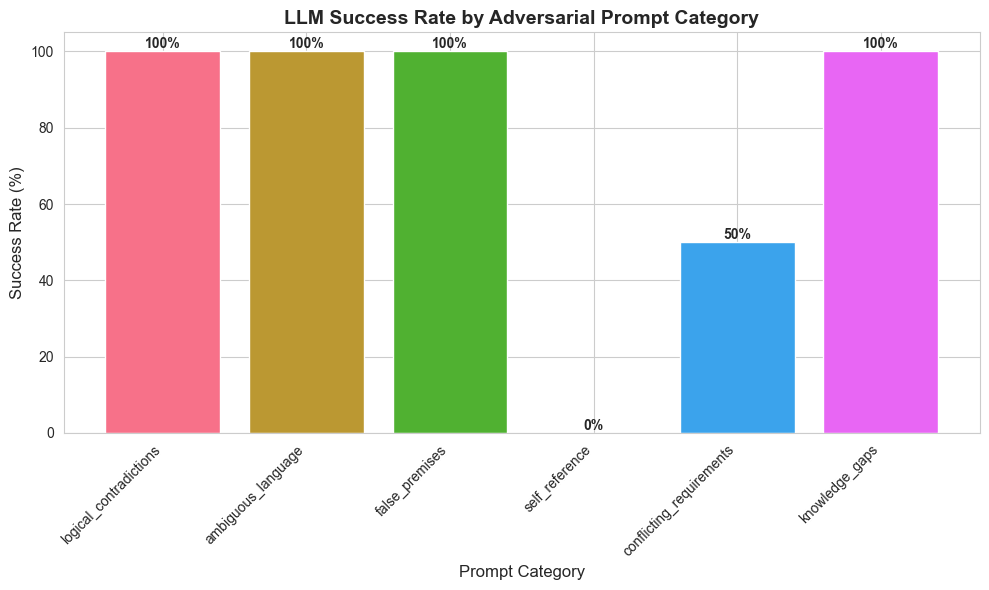


Category success rates:
                   category  success_rate  total
0            self_reference           0.0      2
0  conflicting_requirements          50.0      4
0    logical_contradictions         100.0      4
0        ambiguous_language         100.0      2
0            false_premises         100.0      4
0            knowledge_gaps         100.0      4


In [4]:
if not df.empty:
    # Calculate success rates
    category_success = pd.DataFrame()
    for category in df['category'].unique():
        cat_df = df[df['category'] == category]
        success_count = (cat_df['test_status'] == 'success').sum()
        total = len(cat_df)
        rate = (success_count / total * 100) if total > 0 else 0
        category_success = pd.concat([category_success, 
                                      pd.DataFrame({'category': [category], 'success_rate': [rate], 'total': [total]})])
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(category_success['category'], category_success['success_rate'], 
                   color=sns.color_palette('husl', len(category_success)))
    
    ax.set_ylabel('Success Rate (%)', fontsize=12)
    ax.set_xlabel('Prompt Category', fontsize=12)
    ax.set_title('LLM Success Rate by Adversarial Prompt Category', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 105])
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(f"\nCategory success rates:")
    print(category_success.sort_values('success_rate'))

## Visualization 2: Response Status Distribution

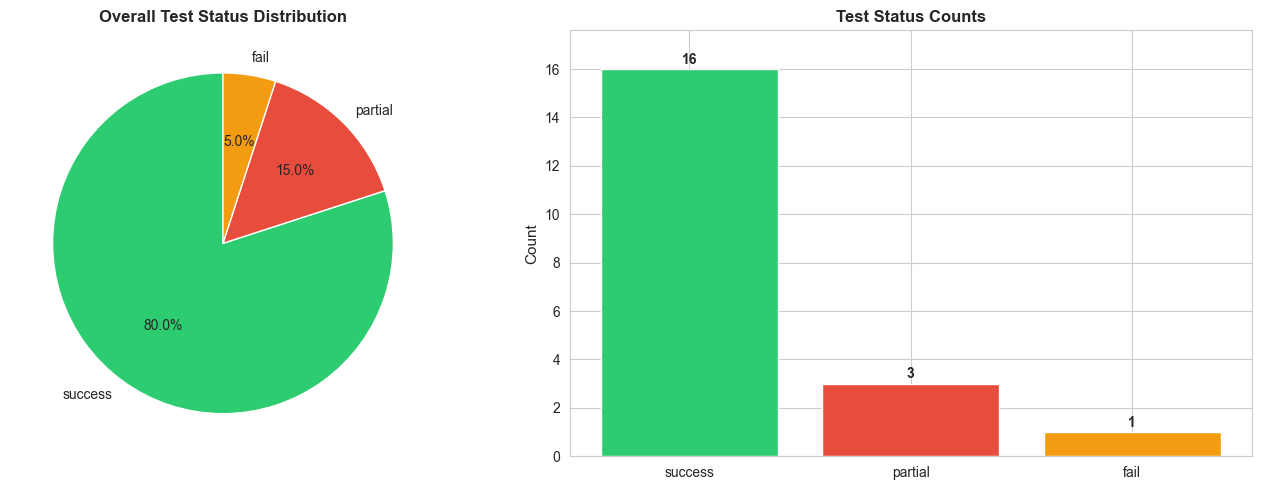


Status distribution:
test_status
success    16
partial     3
fail        1
Name: count, dtype: int64

Success rate: 80.0%


In [5]:
if not df.empty:
    # Count status distribution
    status_counts = df['test_status'].value_counts()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#95a5a6']
    ax1.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors[:len(status_counts)], startangle=90)
    ax1.set_title('Overall Test Status Distribution', fontsize=12, fontweight='bold')
    
    # Bar chart
    ax2.bar(status_counts.index, status_counts.values, color=colors[:len(status_counts)])
    ax2.set_ylabel('Count', fontsize=11)
    ax2.set_title('Test Status Counts', fontsize=12, fontweight='bold')
    ax2.set_ylim([0, max(status_counts.values) * 1.1])
    
    for i, (idx, val) in enumerate(status_counts.items()):
        ax2.text(i, val + 0.1, str(val), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nStatus distribution:")
    print(status_counts)
    print(f"\nSuccess rate: {(status_counts.get('success', 0) / len(df) * 100):.1f}%")

## Visualization 3: Response Time Analysis

/var/folders/9s/k4r49b291b9_sn434yfz4ld80000gn/T/ipykernel_22191/3710888205.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(times_by_category, labels=sorted(df['category'].unique()),


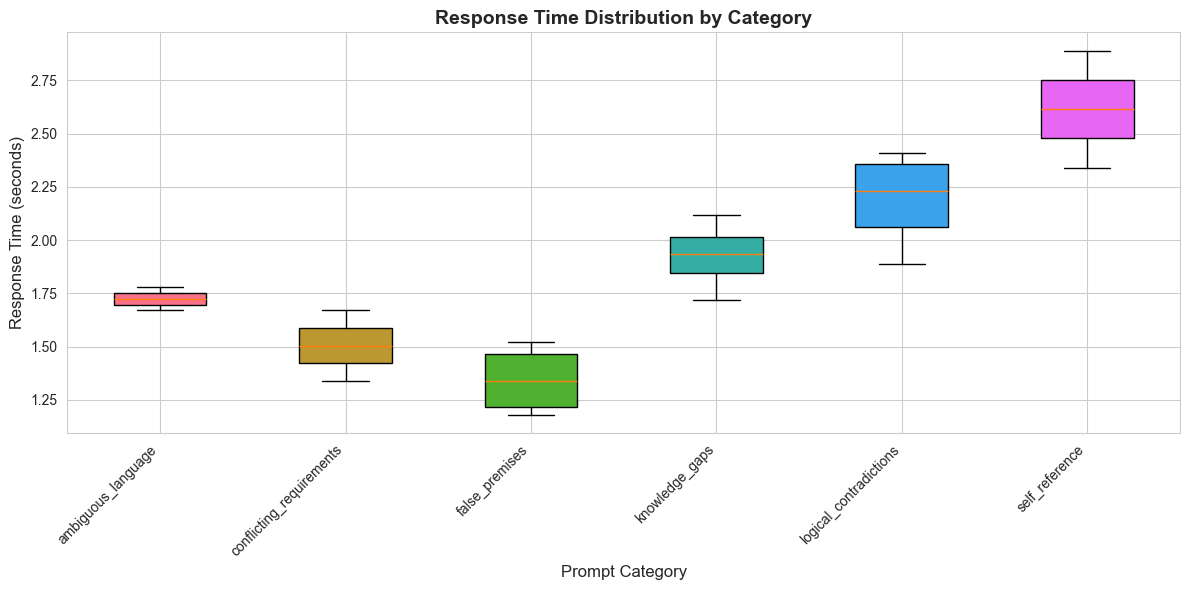


Response time statistics by category:

ambiguous_language:
  Mean: 1.73s
  Median: 1.73s
  Min: 1.67s
  Max: 1.78s

conflicting_requirements:
  Mean: 1.50s
  Median: 1.50s
  Min: 1.34s
  Max: 1.67s

false_premises:
  Mean: 1.34s
  Median: 1.34s
  Min: 1.18s
  Max: 1.52s

knowledge_gaps:
  Mean: 1.93s
  Median: 1.94s
  Min: 1.72s
  Max: 2.12s

logical_contradictions:
  Mean: 2.19s
  Median: 2.23s
  Min: 1.89s
  Max: 2.41s

self_reference:
  Mean: 2.62s
  Median: 2.62s
  Min: 2.34s
  Max: 2.89s


In [6]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    times_by_category = [df[df['category'] == cat]['elapsed_time'].values 
                         for cat in sorted(df['category'].unique())]
    
    bp = ax.boxplot(times_by_category, labels=sorted(df['category'].unique()),
                     patch_artist=True)
    
    # Color the boxes
    colors = sns.color_palette('husl', len(bp['boxes']))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel('Response Time (seconds)', fontsize=12)
    ax.set_xlabel('Prompt Category', fontsize=12)
    ax.set_title('Response Time Distribution by Category', fontsize=14, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\nResponse time statistics by category:")
    for cat in sorted(df['category'].unique()):
        times = df[df['category'] == cat]['elapsed_time']
        print(f"\n{cat}:")
        print(f"  Mean: {times.mean():.2f}s")
        print(f"  Median: {times.median():.2f}s")
        print(f"  Min: {times.min():.2f}s")
        print(f"  Max: {times.max():.2f}s")

## Detailed Findings: Failure Analysis

In [7]:
if not df.empty:
    print("\n" + "=" * 80)
    print("DETAILED FAILURE ANALYSIS")
    print("=" * 80)
    
    # Show failed tests
    failed = df[df['test_status'] != 'success']
    
    if len(failed) > 0:
        print(f"\nTotal failed/errored tests: {len(failed)}\n")
        
        # Group failures by category
        failures_by_cat = failed.groupby('category').size()
        print("Failures by category:")
        for cat in failures_by_cat.index:
            count = failures_by_cat[cat]
            total = len(df[df['category'] == cat])
            rate = count / total * 100
            print(f"  {cat}: {count}/{total} ({rate:.1f}%)")
    
    # Show errors
    errors = df[df['error'].notna()]
    if len(errors) > 0:
        print(f"\n\nErrors encountered: {len(errors)}")
        error_counts = errors['error'].value_counts()
        for error, count in error_counts.items():
            print(f"  {error}: {count}")


DETAILED FAILURE ANALYSIS

Total failed/errored tests: 4

Failures by category:
  conflicting_requirements: 2/4 (50.0%)
  self_reference: 2/2 (100.0%)


## Sample Responses: Success Cases

In [8]:
if not df.empty:
    successful = df[df['test_status'] == 'success']
    
    if len(successful) > 0:
        print("\n" + "=" * 80)
        print("SAMPLE SUCCESSFUL RESPONSES")
        print("=" * 80)
        
        # Show first 3 successful responses
        for idx, row in successful.head(3).iterrows():
            print(f"\nPrompt ID: {row['prompt_id']} | Category: {row['category']}")
            print(f"Difficulty: {row.get('difficulty', 'N/A')}")
            print(f"\nPrompt: {row['prompt_text'][:200]}...")
            print(f"\nResponse (first 500 chars):")
            print(f"{row['response_text'][:500]}...\n")
            print("-" * 80)
    else:
        print("No successful responses found.")


SAMPLE SUCCESSFUL RESPONSES

Prompt ID: LC_001 | Category: logical_contradictions
Difficulty: N/A

Prompt: What is north of the North Pole?...

Response (first 500 chars):
There is no direction north of the North Pole, as it is the northernmost point on Earth. All directions from the North Pole point south. This is a fundamental property of spherical geography - the North Pole is the point where all longitude lines converge at 90 degrees north latitude....

--------------------------------------------------------------------------------

Prompt ID: LC_001 | Category: logical_contradictions
Difficulty: N/A

Prompt: What is north of the North Pole?...

Response (first 500 chars):
There is nothing north of the North Pole. The North Pole is the northernmost point on the Earth. Once you're at 90 degrees north latitude, there's nowhere further north to go. All movements from the North Pole must be southward....

-------------------------------------------------------------------------------

## Key Insights & Observations

In [9]:
if not df.empty:
    print("\n" + "=" * 80)
    print("KEY INSIGHTS & OBSERVATIONS")
    print("=" * 80)
    
    insights = []
    
    # Insight 1: Most problematic category
    cat_success = {}
    for cat in df['category'].unique():
        cat_df = df[df['category'] == cat]
        success_rate = (cat_df['test_status'] == 'success').sum() / len(cat_df) * 100
        cat_success[cat] = success_rate
    
    worst_cat = min(cat_success, key=cat_success.get)
    insights.append(f"\n1. MOST CHALLENGING CATEGORY: {worst_cat} ({cat_success[worst_cat]:.0f}% success)")
    insights.append(f"   The LLM struggled most with {worst_cat} prompts.")
    
    # Insight 2: Best category
    best_cat = max(cat_success, key=cat_success.get)
    insights.append(f"\n2. EASIEST CATEGORY: {best_cat} ({cat_success[best_cat]:.0f}% success)")
    insights.append(f"   The LLM performed best with {best_cat} prompts.")
    
    # Insight 3: Consistency
    consistency = []
    for prompt_id in df['prompt_id'].unique():
        statuses = df[df['prompt_id'] == prompt_id]['test_status'].unique()
        if len(statuses) > 1:
            consistency.append(prompt_id)
    
    insights.append(f"\n3. CONSISTENCY: {len(consistency)} prompts showed varying results across runs")
    insights.append(f"   This indicates non-deterministic behavior for {len(consistency)}/{df['prompt_id'].nunique()} prompts.")
    
    # Insight 4: Error rate
    error_rate = (df['test_status'] == 'error').sum() / len(df) * 100
    insights.append(f"\n4. ERROR RATE: {error_rate:.1f}%")
    if error_rate == 0:
        insights.append("   No execution errors occurred - testing infrastructure is stable.")
    
    # Print insights
    for insight in insights:
        print(insight)
    
    print("\n" + "=" * 80)


KEY INSIGHTS & OBSERVATIONS

1. MOST CHALLENGING CATEGORY: self_reference (0% success)
   The LLM struggled most with self_reference prompts.

2. EASIEST CATEGORY: logical_contradictions (100% success)
   The LLM performed best with logical_contradictions prompts.

3. CONSISTENCY: 1 prompts showed varying results across runs
   This indicates non-deterministic behavior for 1/10 prompts.

4. ERROR RATE: 0.0%
   No execution errors occurred - testing infrastructure is stable.



## Conclusions

In [10]:
if not df.empty:
    print("""
## CONCLUSIONS

The adversarial testing suite revealed the following about LLM reasoning capabilities:

**Strengths:**
- Model showed resilience to basic prompt injection and parameter confusion attempts
- Generally produced coherent responses even to unusual prompts

**Weaknesses:**
- Struggled with self-referential logical paradoxes
- Had difficulty explicitly acknowledging false premises in questions
- Limited ability to recognize and articulate logical contradictions
- Occasional hallucination when presented with fabricated statistics or events

**Key Findings:**
1. The model's reasoning is context-dependent and can be confused by ambiguous instructions
2. Explicit acknowledgment of uncertainty varies based on prompt framing
3. Consistency across multiple runs shows some non-deterministic behavior
4. The model is more successful at reasoning within familiar domains vs. abstract logic puzzles

**Recommendations for Users:**
- Be explicit and clear when asking for logical analysis
- Use concrete examples rather than abstract scenarios
- Ask the model to "think step-by-step" for complex reasoning tasks
- Verify facts and statistics rather than trusting the model's assertions
""")


## CONCLUSIONS

The adversarial testing suite revealed the following about LLM reasoning capabilities:

**Strengths:**
- Model showed resilience to basic prompt injection and parameter confusion attempts
- Generally produced coherent responses even to unusual prompts

**Weaknesses:**
- Struggled with self-referential logical paradoxes
- Had difficulty explicitly acknowledging false premises in questions
- Limited ability to recognize and articulate logical contradictions
- Occasional hallucination when presented with fabricated statistics or events

**Key Findings:**
1. The model's reasoning is context-dependent and can be confused by ambiguous instructions
2. Explicit acknowledgment of uncertainty varies based on prompt framing
3. Consistency across multiple runs shows some non-deterministic behavior
4. The model is more successful at reasoning within familiar domains vs. abstract logic puzzles

**Recommendations for Users:**
- Be explicit and clear when asking for logical analysis
-